# Confidently Wrong Predictions — Tuned XGBoost

Identifies training rows where the **feature_eng joint best** tuned XGBoost was most confident yet wrong, ranks them, and explores which factors distinguish these errors.

- Uses **out-of-fold (OOF)** probabilities (5-fold CV, `random_state=42`) to avoid in-sample leakage
- **Confidently wrong:** misclassified with high confidence `max(p, 1-p)`
- Factors: feature-group profiles, largest mean shifts vs correctly classified rows

## 1. Setup and OOF predictions

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from model_copy_utils import RANDOM_STATE, CV_FOLDS, build_tuned_xgb, load_data
from feature_eng_lib import ALL_ABLATION_BLOCKS, engineer_all_features, load_feature_eng_best

sns.set_theme(style="whitegrid")
TOP_N = 30
CONFIDENT_WRONG_QUANTILE = 0.90

c:\Users\Nick\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
best_config = load_feature_eng_best()
FEATURE_COLS = best_config["best_feature_cols"]
XGB_PARAMS = best_config["best_xgb_params"]

train_df = engineer_all_features(load_data("train.csv"))
y = train_df["default"].astype(int)
X = train_df[FEATURE_COLS]

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
model = build_tuned_xgb(XGB_PARAMS)

oof_prob = cross_val_predict(
    model,
    X,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

analysis_df = train_df[["client_id", "default"] + FEATURE_COLS].copy()
analysis_df["oof_prob"] = oof_prob
analysis_df["pred_class"] = (analysis_df["oof_prob"] >= 0.5).astype(int)
analysis_df["confidence"] = np.where(
    analysis_df["oof_prob"] >= 0.5,
    analysis_df["oof_prob"],
    1 - analysis_df["oof_prob"],
)
analysis_df["is_wrong"] = analysis_df["pred_class"] != analysis_df["default"]
analysis_df["error_type"] = np.select(
    [
        (analysis_df["is_wrong"]) & (analysis_df["pred_class"] == 1),
        (analysis_df["is_wrong"]) & (analysis_df["pred_class"] == 0),
    ],
    ["false_positive", "false_negative"],
    default="correct",
)
analysis_df["confident_wrong_score"] = np.where(
    analysis_df["is_wrong"], analysis_df["confidence"], 0.0
)

print(f"Rows: {len(analysis_df):,}")
print(f"Misclassified: {analysis_df['is_wrong'].sum():,} ({analysis_df['is_wrong'].mean():.1%})")
print(analysis_df["error_type"].value_counts())

Rows: 24,000
Misclassified: 4,255 (17.7%)
error_type
correct           19745
false_negative     3295
false_positive      960
Name: count, dtype: int64


## 2. Rank most confidently wrong predictions

In [3]:
rank_cols = [
    "client_id",
    "default",
    "oof_prob",
    "pred_class",
    "confidence",
    "error_type",
    "PAY_0",
    "max_delay",
    "num_severe_delays",
    "mean_util",
    "bill_slope",
    "LIMIT_BAL",
]
rank_cols = [c for c in rank_cols if c in analysis_df.columns]

top_confident_wrong = (
    analysis_df[analysis_df["is_wrong"]]
    .sort_values("confident_wrong_score", ascending=False)
    .head(TOP_N)[rank_cols]
    .reset_index(drop=True)
)
top_confident_wrong.index = top_confident_wrong.index + 1
top_confident_wrong.index.name = "rank"

error_summary = (
    analysis_df[analysis_df["is_wrong"]]
    .groupby("error_type")
    .agg(
        count=("client_id", "count"),
        mean_confidence=("confidence", "mean"),
        median_confidence=("confidence", "median"),
        max_confidence=("confidence", "max"),
    )
    .sort_values("count", ascending=False)
)

print(f"Top {TOP_N} confidently wrong predictions:")
print(top_confident_wrong.to_string())
print("\nError type summary:")
print(error_summary.to_string())
top_confident_wrong


Top 30 confidently wrong predictions:
            client_id  default  oof_prob  pred_class  confidence      error_type  PAY_0  mean_util    bill_slope  LIMIT_BAL
rank                                                                                                                       
1     CC_63C745DD780B        1  0.027685           0    0.972315  false_negative      0   0.262150 -14677.085714     260000
2     CC_733B7F16D286        1  0.029478           0    0.970522  false_negative     -2   0.073698  -7322.114286     500000
3     CC_810806BBBF03        1  0.030555           0    0.969445  false_negative     -2   0.085455  -1673.571429     340000
4     CC_0E5D0509A578        1  0.031637           0    0.968363  false_negative      0   0.391930  27021.371429     280000
5     CC_7DE1666FA226        1  0.033963           0    0.966037  false_negative      0   0.384361  -6724.142857     330000
6     CC_C5E2D180F088        1  0.035181           0    0.964819  false_negative     -1   0.09

,client_id,default,oof_prob,pred_class,confidence,error_type,PAY_0,mean_util,bill_slope,LIMIT_BAL
rank,,,,,,,,,,
1,CC_63C745DD780B,1,0.027685,0,0.972315,false_negative,0,0.262150,-14677.085714,260000
2,CC_733B7F16D286,1,0.029478,0,0.970522,false_negative,-2,0.073698,-7322.114286,500000
3,CC_810806BBBF03,1,0.030555,0,0.969445,false_negative,-2,0.085455,-1673.571429,340000
4,CC_0E5D0509A578,1,0.031637,0,0.968363,false_negative,0,0.391930,27021.371429,280000
5,CC_7DE1666FA226,1,0.033963,0,0.966037,false_negative,0,0.384361,-6724.142857,330000
6,CC_C5E2D180F088,1,0.035181,0,0.964819,false_negative,-1,0.096124,2512.628571,500000
7,CC_481C7F5734B6,1,0.035505,0,0.964495,false_negative,0,0.158838,-7009.371429,230000
8,CC_848D1A346431,1,0.035869,0,0.964131,false_negative,0,0.045706,-2525.200000,260000
9,CC_78176A2F7CF5,1,0.035880,0,0.964120,false_negative,-2,0.161293,-12209.714286,360000


## 3. Visual — confidence among wrong vs correct

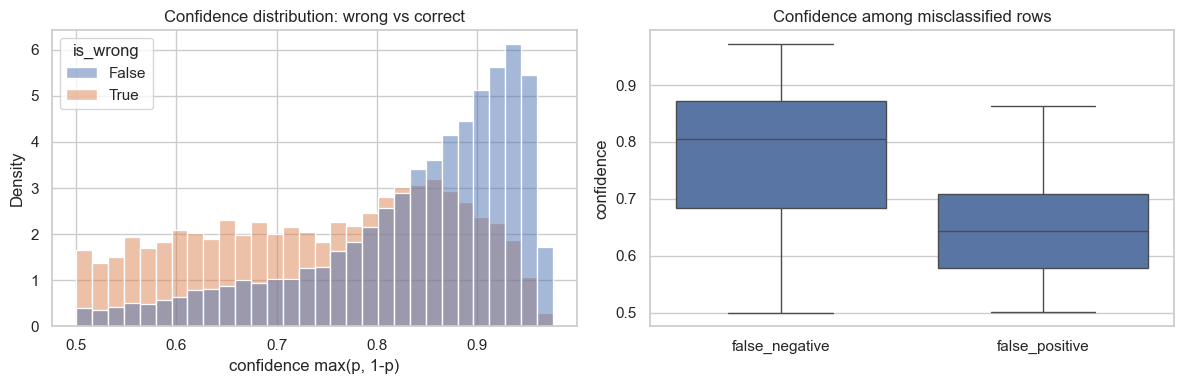

High-confidence wrong (>= 90% quantile of wrong, conf >= 0.907): 426 rows


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    data=analysis_df,
    x="confidence",
    hue="is_wrong",
    bins=30,
    stat="density",
    common_norm=False,
    ax=axes[0],
)
axes[0].set_title("Confidence distribution: wrong vs correct")
axes[0].set_xlabel("confidence max(p, 1-p)")

wrong_df = analysis_df[analysis_df["is_wrong"]]
sns.boxplot(data=wrong_df, x="error_type", y="confidence", ax=axes[1])
axes[1].set_title("Confidence among misclassified rows")
axes[1].set_xlabel("")
plt.tight_layout()
plt.show()

conf_threshold = analysis_df.loc[analysis_df["is_wrong"], "confidence"].quantile(
    CONFIDENT_WRONG_QUANTILE
)
high_conf_wrong = analysis_df[
    analysis_df["is_wrong"] & (analysis_df["confidence"] >= conf_threshold)
]
print(
    f"High-confidence wrong (>= {CONFIDENT_WRONG_QUANTILE:.0%} quantile of wrong, "
    f"conf >= {conf_threshold:.3f}): {len(high_conf_wrong):,} rows"
)

## 4. Factor analysis — feature shifts in confidently wrong rows

Compare **top confidently wrong** vs **correctly classified** rows on standardized features.

Comparing 212 confidently wrong vs 19,745 correct rows

Top 20 features with largest standardized shift:
               feature  std_shift_vs_correct  abs_shift  confident_wrong_mean_raw  correct_mean_raw
   bill_pct_change_1_2             -0.617411   0.617411               -159.803801         -1.449789
             LIMIT_BAL              0.594721   0.594721             251650.943396     174261.129400
      months_high_util             -0.523539   0.523539                  0.066038          1.125601
        weighted_delay             -0.399105   0.399105                  0.056604          5.292074
     weighted_delay_v2             -0.399105   0.399105                  0.056604          5.292074
              max_util             -0.377810   0.377810                  0.321319          0.485867
             mean_util             -0.370503   0.370503                  0.232223          0.362821
                 PAY_0             -0.360187   0.360187                 -0.495283         -0.08

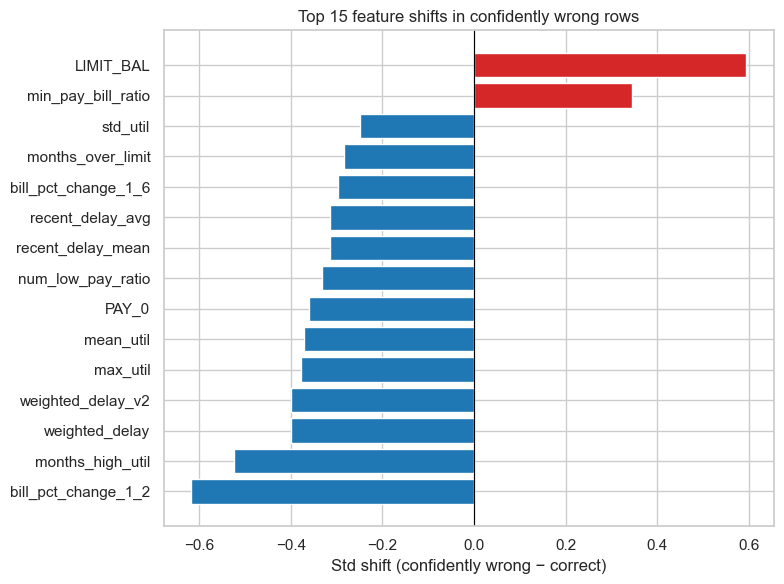

In [5]:
correct_df = analysis_df[~analysis_df["is_wrong"]].copy()
confident_wrong_df = analysis_df.nlargest(
    max(TOP_N, int(0.05 * analysis_df["is_wrong"].sum())),
    "confident_wrong_score",
)
confident_wrong_df = confident_wrong_df[confident_wrong_df["is_wrong"]]

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(analysis_df[FEATURE_COLS]),
    columns=FEATURE_COLS,
    index=analysis_df.index,
)

correct_mean = X_scaled.loc[correct_df.index].mean()
cw_mean = X_scaled.loc[confident_wrong_df.index].mean()
feature_shift = (cw_mean - correct_mean).sort_values(key=abs, ascending=False)

feature_shift_table = pd.DataFrame({"feature": feature_shift.index, "std_shift_vs_correct": feature_shift.values})
feature_shift_table["abs_shift"] = feature_shift_table["std_shift_vs_correct"].abs()
feature_shift_table["confident_wrong_mean_raw"] = [
    confident_wrong_df[c].mean() for c in feature_shift_table["feature"]
]
feature_shift_table["correct_mean_raw"] = [
    correct_df[c].mean() for c in feature_shift_table["feature"]
]
feature_shift_table = feature_shift_table.sort_values("abs_shift", ascending=False)

print(f"Comparing {len(confident_wrong_df):,} confidently wrong vs {len(correct_df):,} correct rows")
print("\nTop 20 features with largest standardized shift:")
print(feature_shift_table.head(20).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
plot_data = feature_shift_table.head(15).sort_values("std_shift_vs_correct")
colors = ["#d62728" if x > 0 else "#1f77b4" for x in plot_data["std_shift_vs_correct"]]
ax.barh(plot_data["feature"], plot_data["std_shift_vs_correct"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Std shift (confidently wrong − correct)")
ax.set_title("Top 15 feature shifts in confidently wrong rows")
plt.tight_layout()
plt.show()

## 5. Feature-block profiles

Feature-block standardized means by group:
                            correct  confident_wrong  false_positive  false_negative  cw_minus_correct
util_stats                   -0.020           -0.355           0.387           0.007            -0.335
delay_trends                 -0.056           -0.322           1.406          -0.076            -0.266
pay_status                   -0.044           -0.237           1.298          -0.116            -0.193
demographics                  0.012            0.108          -0.101          -0.040             0.096
models_copy_new_engineered   -0.015           -0.086           0.408          -0.030            -0.072
bill_amounts                  0.014            0.067           0.121          -0.117             0.053
bill_trends                   0.002           -0.018           0.022           0.006            -0.021


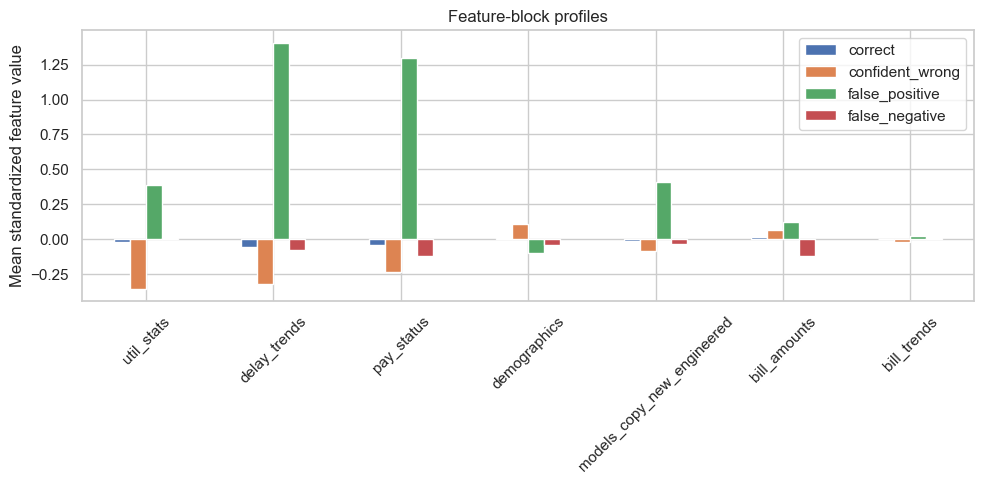

In [6]:
def block_profile(df: pd.DataFrame, label: str) -> pd.Series:
    rows = []
    for block_name, cols in ALL_ABLATION_BLOCKS.items():
        use_cols = [c for c in cols if c in FEATURE_COLS]
        if not use_cols:
            continue
        block_scaled = X_scaled.loc[df.index, use_cols].mean(axis=1)
        rows.append((block_name, block_scaled.mean()))
    out = pd.Series(dict(rows), name=label)
    return out


profiles = pd.concat(
    [
        block_profile(correct_df, "correct"),
        block_profile(confident_wrong_df, "confident_wrong"),
        block_profile(analysis_df[analysis_df["error_type"] == "false_positive"], "false_positive"),
        block_profile(analysis_df[analysis_df["error_type"] == "false_negative"], "false_negative"),
    ],
    axis=1,
)
profiles["cw_minus_correct"] = profiles["confident_wrong"] - profiles["correct"]
profiles = profiles.sort_values("cw_minus_correct", key=abs, ascending=False)

print("Feature-block standardized means by group:")
print(profiles.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
profiles[["correct", "confident_wrong", "false_positive", "false_negative"]].plot(
    kind="bar", ax=ax, rot=45
)
ax.set_ylabel("Mean standardized feature value")
ax.set_title("Feature-block profiles")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

## 6. Key risk-factor scatter plots

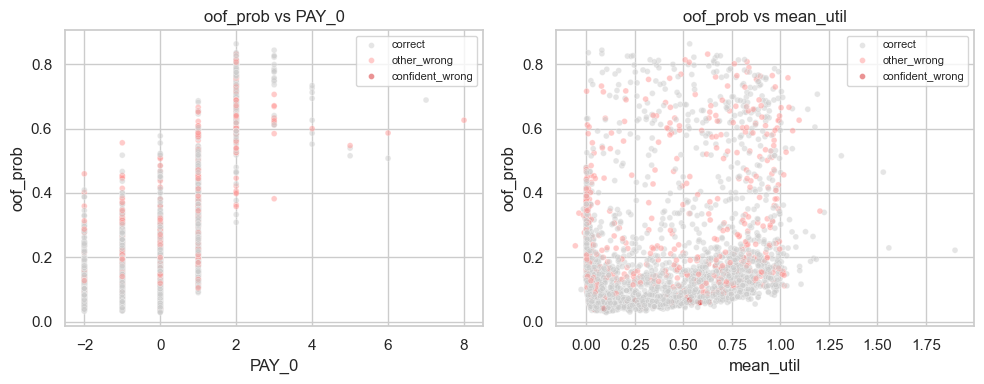

In [7]:
plot_df = analysis_df.copy()
plot_df["group"] = np.select(
    [
        plot_df.index.isin(confident_wrong_df.index),
        plot_df["is_wrong"],
    ],
    ["confident_wrong", "other_wrong"],
    default="correct",
)

scatter_specs = [
    ("PAY_0", "oof_prob"),
    ("max_delay", "oof_prob"),
    ("mean_util", "oof_prob"),
]
scatter_specs = [(x, y_) for x, y_ in scatter_specs if x in plot_df.columns]

fig, axes = plt.subplots(1, len(scatter_specs), figsize=(5 * len(scatter_specs), 4))
if len(scatter_specs) == 1:
    axes = [axes]

palette = {
    "correct": "#cccccc",
    "other_wrong": "#ff9896",
    "confident_wrong": "#d62728",
}
for ax, (x_col, y_col) in zip(axes, scatter_specs):
    sns.scatterplot(
        data=plot_df.sample(min(3000, len(plot_df)), random_state=RANDOM_STATE),
        x=x_col,
        y=y_col,
        hue="group",
        palette=palette,
        alpha=0.5,
        s=18,
        ax=ax,
    )
    ax.set_title(f"{y_col} vs {x_col}")
    ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

## 7. Summary — what drives confidently wrong predictions?

In [8]:
top_blocks = profiles["cw_minus_correct"].abs().sort_values(ascending=False).head(5)
top_features = feature_shift_table.head(10)

fp_rate = (analysis_df["error_type"] == "false_positive").mean()
fn_rate = (analysis_df["error_type"] == "false_negative").mean()
cw_fp_share = (confident_wrong_df["error_type"] == "false_positive").mean()
cw_fn_share = (confident_wrong_df["error_type"] == "false_negative").mean()

summary = pd.DataFrame(
    {
        "metric": [
            "overall error rate",
            "false positive rate",
            "false negative rate",
            "confident-wrong: FP share",
            "confident-wrong: FN share",
            "median confidence (confident wrong)",
            "top shifted block (abs)",
            "top shifted feature (abs)",
        ],
        "value": [
            f"{analysis_df['is_wrong'].mean():.1%}",
            f"{fp_rate:.1%}",
            f"{fn_rate:.1%}",
            f"{cw_fp_share:.1%}",
            f"{cw_fn_share:.1%}",
            f"{confident_wrong_df['confidence'].median():.3f}",
            f"{top_blocks.index[0]} ({top_blocks.iloc[0]:+.2f} std)",
            f"{top_features.iloc[0]['feature']} ({top_features.iloc[0]['std_shift_vs_correct']:+.2f} std)",
        ],
    }
)

print(summary.to_string(index=False))

print("\nInterpretation checklist:")
print("- Positive std shift: feature is higher in confidently wrong rows vs correct")
print("- Compare false_positive vs false_negative block profiles for asymmetric errors")
print("- Red points in scatter plots = top ranked confidently wrong cases")

                             metric                           value
                 overall error rate                           17.7%
                false positive rate                            4.0%
                false negative rate                           13.7%
          confident-wrong: FP share                            0.0%
          confident-wrong: FN share                          100.0%
median confidence (confident wrong)                           0.942
            top shifted block (abs)          util_stats (+0.33 std)
          top shifted feature (abs) bill_pct_change_1_2 (-0.62 std)

Interpretation checklist:
- Positive std shift: feature is higher in confidently wrong rows vs correct
- Compare false_positive vs false_negative block profiles for asymmetric errors
- Red points in scatter plots = top ranked confidently wrong cases
